Import Statements

In [11]:
%matplotlib inline
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

import czifile
import cv2 as cv
from cellpose import models
from shapely import Polygon, distance
from skimage import exposure, morphology
from skimage.filters import threshold_otsu, gaussian
from skimage.measure import label, regionprops, find_contours
from skimage.morphology import remove_small_objects, disk, binary_dilation
from skimage.segmentation import relabel_sequential, clear_border

PARAMETERS

In [34]:
IMAGE_FOLDER   = "102225_MFI_lipid_droplet_starvation"
FILE_EXTENSION = "*.czi"
RESULTS_FOLDER = "Results"

USE_GPU            = True
CELLPOSE_DIAMETER  = 150 #Too high = merges cells; too low = splits cells
#old: 120

#cell-segmentation thresholds
FLOW_THRESH_BRIGHT = 1 #Lower = stricter, fewer false cells
#0.6, old 0.7
PROB_THRESH_BRIGHT = -10 #More negative = accepts dimmer/weaker cells ADJUST THIS!!!
#-3
FLOW_THRESH_DIM    = 0.3
PROB_THRESH_DIM    = -6.0 #More negative = casts wider net for faint dim cells
CELL_MIN_AREA      = 300 #Lower = keeps smaller cells

#mitochondria segmentation thresholds
MINIMUM_MITO_THRESH = 0.1

OUTPUT_FILENAME = "102225_lipid_mfi_per_cell.csv"

os.makedirs(RESULTS_FOLDER, exist_ok=True)

#init cellpose 3 model (tries cyto3, falls back to cyto2 if download fails)
print("Initializing Cellpose 3 (cyto3)...")
try:
    model = models.Cellpose(gpu=USE_GPU, model_type='cyto3')
    print(f"  cyto3 ready  |  GPU={USE_GPU}")
except Exception as e:
    print(f"  cyto3 failed ({e}), falling back to cyto2")
    model = models.Cellpose(gpu=USE_GPU, model_type='cyto2')
print("Parameters set.")

Initializing Cellpose 3 (cyto3)...
  cyto3 ready  |  GPU=True
Parameters set.


Helper Functions

In [35]:
contours = []

def normalize_image(image): #returns normalized image
    """Min-max normalize to float64 [0, 1]."""
    img = image.astype(np.float64)
    mn, mx = img.min(), img.max()
    return np.zeros_like(img) if mx == mn else (img - mn) / (mx - mn)


def boost_contrast_visual(image): #returns image with improved exposure
    """Percentile stretch for DISPLAY ONLY."""
    p_lo, p_hi = np.percentile(image, (1, 99.5))
    return exposure.rescale_intensity(image, in_range=(p_lo, p_hi))


def load_channels(filepath):
    """Load .czi and return (green_raw, red_raw) as 2D arrays."""
    try:
        czi = czifile.CziFile(filepath)
        img = np.squeeze(czi.asarray())
    except Exception as e:
        print(f"  [ERROR] File load failed: {e}")
        return None, None

    ch0 = ch1 = None
    if img.ndim == 3 and img.shape[0] in (2, 3, 4):
        ch0, ch1 = img[0], img[1]
    elif img.ndim == 3 and img.shape[-1] in (2, 3, 4):
        ch0, ch1 = img[..., 0], img[..., 1]
    else:
        print(f"  [ERROR] Unexpected shape: {img.shape}")
        return None, None

    return (ch0, ch1)


# ── CELL SEGMENTATION — dual-pass Cellpose 3 ──────────────────────────────────
def segment_cells_single_pass(nuclei_channel, cyto_channel):
    """
    Single-pass Cellpose 3 segmentation.

    This removes the bright/dim two-pass merge logic, which can introduce
    odd shapes and missed cells when the two passes disagree. The function
    runs Cellpose once on a gently normalized image and then applies only
    minimal cleanup.
    Returns a 2D integer label array (0=background, 1..N=cells).
    """
    if model is None:
        print("  [ERROR] Model not initialized.")
        return None

    nuclei_norm = normalize_image(nuclei_channel).astype(np.float32)
    cyto_norm = normalize_image(cyto_channel).astype(np.float32)
    img_2ch = np.stack([cyto_norm, nuclei_norm], axis=-1)
    # Channel 1: Cytoplasm - Blue
    # Channel 2: Nuclei - Red
    eval_result = model.eval(
        img_2ch,
        diameter=CELLPOSE_DIAMETER,
        channels=[1, 2],
        flow_threshold=FLOW_THRESH_BRIGHT,
        cellprob_threshold=PROB_THRESH_BRIGHT,
        do_3D=False,
        resample=True,
    )
    masks = eval_result[0]
    print(f"    Single pass:     {masks.max()} masks")

    cleaned = masks.copy().astype(np.int32)

    for rid in range(1, int(cleaned.max()) + 1):
        if (cleaned == rid).sum() < CELL_MIN_AREA:
            cleaned[cleaned == rid] = 0
    final, _, _ = relabel_sequential(cleaned)
    print(f"    Final cells:     {final.max()}")
    return final # integer mask


"""
Adative Threshold Segmentation:
OpenCV's adaptive threshold function returns an image with only the foreground. Image is broken
up into blocks, and if a pixel is greater than the mean - C parameter for the block, the pixel is included. Otherwise
the pixel value becomes 0.
"""

def segment_mito_adaptive(blue_raw):
    blue_uint8 = (normalize_image(blue_raw) * 255).astype(np.uint8)
    blue_blurred = cv.medianBlur(blue_uint8, 5)
    mito_filtered = cv.adaptiveThreshold(blue_blurred, 10, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, -3)
    binary_mito = mito_filtered > 0
    binary_mito = binary_dilation(binary_mito)
    return binary_mito


def segment_lipids_otsu(red_raw):
    """Otsu-based lipid segmentation on normalized red channel."""
    red_blur = gaussian(red_raw)
    red_norm = normalize_image(red_blur)
    try:
        otsu_val     = threshold_otsu(red_norm)
        final_thresh = max(otsu_val, 0.25)
    except Exception:
        final_thresh = 0.25
    binary_lipids = red_norm > final_thresh
    binary_lipids = remove_small_objects(binary_lipids, min_size=10)
    binary_lipids = binary_dilation(binary_lipids)
    return binary_lipids  # boolean mask


def analyze_MFI(red_channel, lipid_masks, labeled_cells, mito_masks): #per cell
    """
    Data to Return:
    - cell id
    - cytoplasm area
    - lipid area
    - lipid MFI
    - # of lipids per cell (even if innacurate)
    """
    mfi_data = {}
    mito_shapes_all = []
    lipid_shapes_all = []

    for prop in regionprops(labeled_cells): #account for no lipids shown in cell
        cell_mask = (labeled_cells == prop.label)
        dilated_cell_mask = binary_dilation(cell_mask)
        lipid_mask = (dilated_cell_mask & lipid_masks)
        mito_mask = (dilated_cell_mask & mito_masks)

        
        labeled_mito = label(mito_mask)
        mito_shapes = []
        for lid in range(1, (labeled_mito.max() + 1)):
            single_mito_mask = (lid == labeled_mito)
            contours = find_contours(single_mito_mask)
            for cont in contours:
                shape = Polygon(cont)
                mito_shapes.append(shape)
                mito_shapes_all.append(shape)

            print("cell")
            print(contours)
            
        

        #if cell doesn't contain mitochondria, skip cell
        mito_area = np.sum(mito_mask)
        if mito_area == 0:
            continue
        n_single_lipids = 0
        single_lipid_area = 0
        n_clustered_lipids = 0
        clustered_lipid_area = 0
        if np.max(lipid_mask) == 0:
            #no lipids exist in the cell, fill in variables for dict
            lipid_area = 0
            lipid_mfi = np.nan
            n_lipids = 0
        else:
            #calculate other masks and fill in variables for dict
            labeled_lipids = label(lipid_mask)
            lipid_values = red_channel[lipid_mask]
            lipid_area = np.sum(lipid_mask)
            lipid_mfi = np.mean(lipid_values)
            n_lipids = labeled_lipids.max()

            #classify lipids into single or clustered based on circularity index
            #Note: the circularity index in used in this code is known as the thinness ratio, and the actual index is the inverse of this formula
            distances = 0
            for lprop in regionprops(labeled_lipids):
                single_lipid_mask = (labeled_lipids == lprop.label)
                area = lprop.area
                per = lprop.perimeter
                circ_index = 4 * np.pi * area / (per ** 2) #Note: account for 
                print(f"Circularity Index: {circ_index}")
                print(f"Perimeter: {per}")

                lipid_cont = find_contours(single_lipid_mask)[0]
                lipid_shape = Polygon(lipid_cont)
                lipid_shapes_all.append(lipid_shape)
                
                min_distance = 100000000000
                for mito_shape in mito_shapes:
                    dist = distance(mito_shape, lipid_shape)
                    if dist < min_distance:
                        min_distance = dist
                    print(dist)

                distances += 1
                if circ_index >= 0.7:
                    n_single_lipids += 1
                    single_lipid_area += area
                else:
                    n_clustered_lipids += 1
                    clustered_lipid_area += area

        mfi_data[prop.label] = {
            "cell_id" : prop.label,
            "cell_area" : prop.area,
            "mito_area" : mito_area,
            "lipid_area" : lipid_area,
            "lipid_mfi" : lipid_mfi,
            "#lipids" : n_lipids,
            "n_single" : n_single_lipids,
            "single_area" : single_lipid_area,
            "n_clustered" : n_clustered_lipids,
            "clustered_area" : clustered_lipid_area,
        }

    return mfi_data, mito_shapes_all, lipid_shapes_all #return dict of dicts

Main Loop

Found 16 file(s) in 102225_MFI_lipid_droplet_starvation
Processing M17D_DMEM_lipidtox_red_mitoBFP_01.czi
    Single pass:     87 masks
    Final cells:     28
Lipid Pixels: 2078
cell
[array([[ 51.5, 301. ],
       [ 51.5, 300. ],
       [ 51.5, 299. ],
       [ 51. , 298.5],
       [ 50.5, 298. ],
       [ 50. , 297.5],
       [ 49.5, 297. ],
       [ 49. , 296.5],
       [ 48. , 296.5],
       [ 47.5, 297. ],
       [ 47. , 297.5],
       [ 46.5, 298. ],
       [ 46. , 298.5],
       [ 45. , 298.5],
       [ 44.5, 298. ],
       [ 44. , 297.5],
       [ 43. , 297.5],
       [ 42.5, 297. ],
       [ 42. , 296.5],
       [ 41. , 296.5],
       [ 40. , 296.5],
       [ 39. , 296.5],
       [ 38.5, 297. ],
       [ 38. , 297.5],
       [ 37. , 297.5],
       [ 36.5, 298. ],
       [ 36. , 298.5],
       [ 35.5, 299. ],
       [ 35. , 299.5],
       [ 34.5, 300. ],
       [ 34.5, 301. ],
       [ 35. , 301.5],
       [ 35.5, 302. ],
       [ 35.5, 303. ],
       [ 36. , 303.5],
       [ 36

C:\Users\jmp732\AppData\Local\Temp\ipykernel_6764\1167294.py:91: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  binary_mito = binary_dilation(binary_mito)
C:\Users\jmp732\AppData\Local\Temp\ipykernel_6764\1167294.py:105: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary_lipids = remove_small_objects(binary_lipids, min_size=10)
C:\Users\jmp732\AppData\Local\Temp\ipykernel_6764\1167294.py:106: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be r

cell
[array([[371.5, 240. ],
       [371. , 239.5],
       [370.5, 240. ],
       [371. , 240.5],
       [371.5, 240. ]]), array([[376.5, 236. ],
       [376.5, 235. ],
       [376. , 234.5],
       [375.5, 234. ],
       [375. , 233.5],
       [374. , 233.5],
       [373. , 233.5],
       [372.5, 234. ],
       [372.5, 235. ],
       [372.5, 236. ],
       [372. , 236.5],
       [371.5, 237. ],
       [371.5, 238. ],
       [371.5, 239. ],
       [372. , 239.5],
       [372.5, 239. ],
       [373. , 238.5],
       [373.5, 238. ],
       [374. , 237.5],
       [375. , 237.5],
       [375.5, 237. ],
       [376. , 236.5],
       [376.5, 236. ]])]
cell
[array([[410.5, 232. ],
       [410.5, 231. ],
       [410.5, 230. ],
       [410. , 229.5],
       [409.5, 229. ],
       [409. , 228.5],
       [408.5, 228. ],
       [408. , 227.5],
       [407.5, 227. ],
       [407. , 226.5],
       [406. , 226.5],
       [405.5, 226. ],
       [405. , 225.5],
       [404. , 225.5],
       [403. , 225

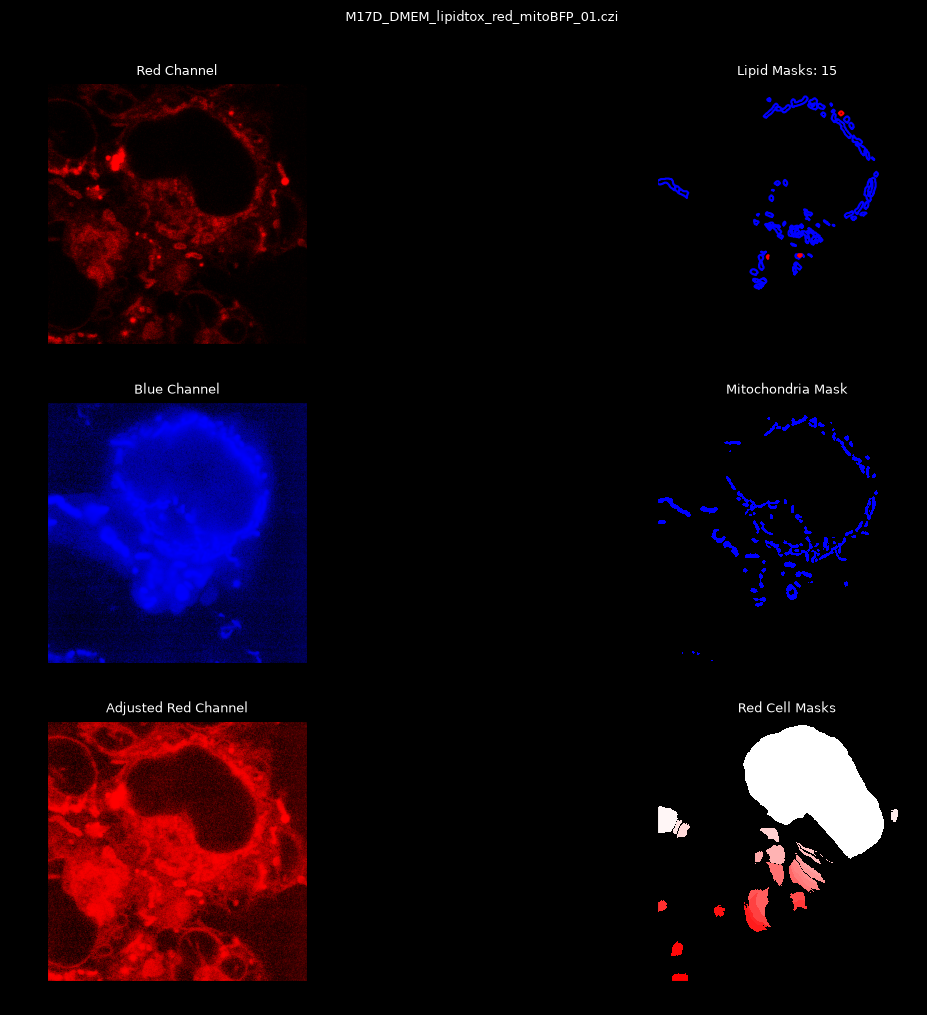

Processing M17D_DMEM_lipidtox_red_mitoBFP_02.czi
    Single pass:     127 masks
    Final cells:     43
Lipid Pixels: 3179
cell
[array([[113.5, 310. ],
       [113. , 309.5],
       [112.5, 309. ],
       [112. , 308.5],
       [111. , 308.5],
       [110.5, 308. ],
       [110.5, 307. ],
       [110. , 306.5],
       [109.5, 307. ],
       [109. , 307.5],
       [108.5, 308. ],
       [108. , 308.5],
       [107.5, 309. ],
       [107. , 309.5],
       [106.5, 310. ],
       [106. , 310.5],
       [105.5, 311. ],
       [105. , 311.5],
       [104.5, 312. ],
       [104. , 312.5],
       [103. , 312.5],
       [102.5, 313. ],
       [102. , 313.5],
       [101.5, 314. ],
       [101.5, 315. ],
       [102. , 315.5],
       [103. , 315.5],
       [103.5, 316. ],
       [104. , 316.5],
       [105. , 316.5],
       [106. , 316.5],
       [106.5, 316. ],
       [107. , 315.5],
       [107.5, 315. ],
       [108. , 314.5],
       [108.5, 314. ],
       [109. , 313.5],
       [109.5, 313. 

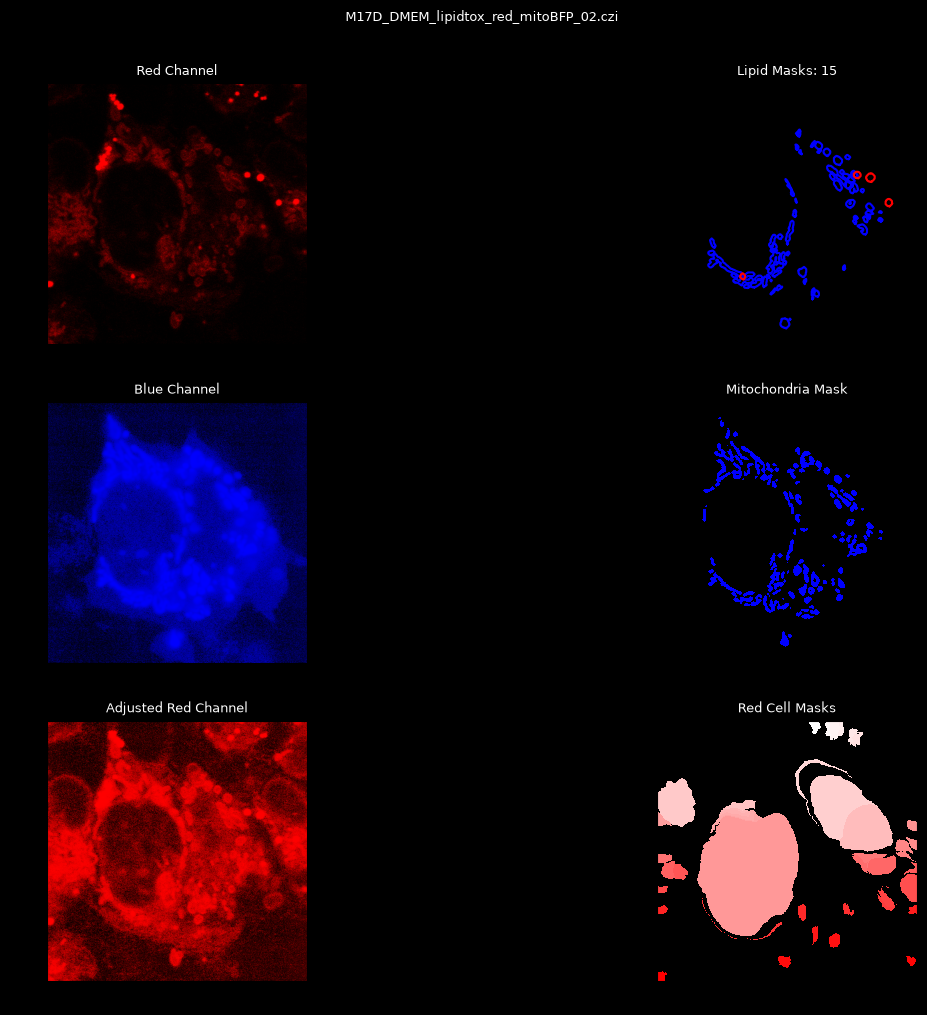

Processing M17D_DMEM_lipidtox_red_mitoBFP_03.czi
    Single pass:     61 masks
    Final cells:     27
Lipid Pixels: 4588
cell
[array([[184.5, 156. ],
       [184.5, 155. ],
       [184.5, 154. ],
       [184.5, 153. ],
       [184. , 152.5],
       [183.5, 152. ],
       [183.5, 151. ],
       [183. , 150.5],
       [182.5, 150. ],
       [182. , 149.5],
       [181. , 149.5],
       [180. , 149.5],
       [179.5, 150. ],
       [179. , 150.5],
       [178. , 150.5],
       [177.5, 151. ],
       [177. , 151.5],
       [176.5, 152. ],
       [176.5, 153. ],
       [176. , 153.5],
       [175.5, 154. ],
       [175. , 154.5],
       [174.5, 155. ],
       [174.5, 156. ],
       [174.5, 157. ],
       [174.5, 158. ],
       [174.5, 159. ],
       [175. , 159.5],
       [175.5, 160. ],
       [175. , 160.5],
       [174.5, 161. ],
       [174.5, 162. ],
       [174.5, 163. ],
       [174. , 163.5],
       [173.5, 164. ],
       [173.5, 165. ],
       [173.5, 166. ],
       [173.5, 167. ]

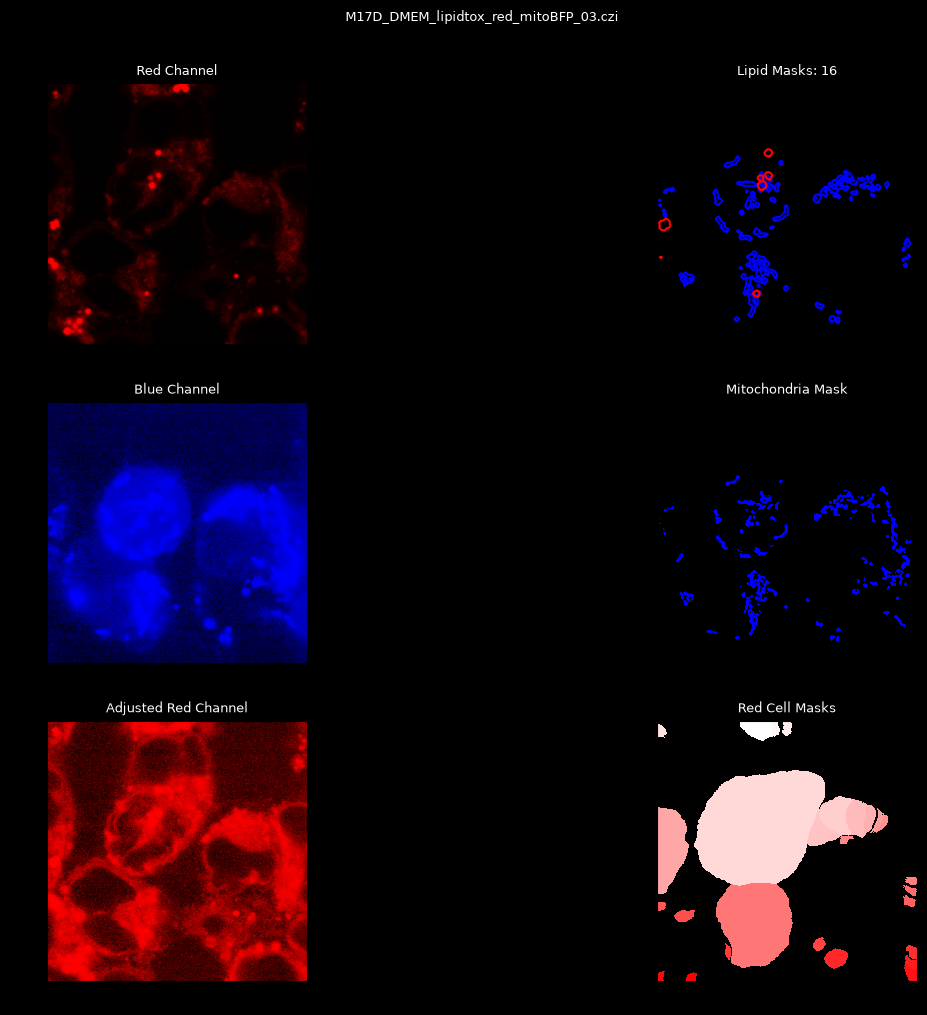

Processing M17D_DMEM_lipidtox_red_mitoBFP_04.czi


KeyboardInterrupt: 

In [36]:
# color maps
cmap_green = LinearSegmentedColormap.from_list("G", [(0,0,0),(0,1,0)])
cmap_red   = LinearSegmentedColormap.from_list("R", [(0,0,0),(1,0,0)])
cmap_red_inv = LinearSegmentedColormap.from_list("RI", [(1, 1, 1),(1,0,0)])
cmap_blue = LinearSegmentedColormap.from_list("B", [(0, 0, 0), (0, 0, 1)])

all_results = []

image_files = sorted(glob.glob(os.path.join(IMAGE_FOLDER, FILE_EXTENSION)))
print(f"Found {len(image_files)} file(s) in {IMAGE_FOLDER}")

for filepath in image_files:
    filename = os.path.basename(filepath)
    print(f"Processing {filename}")

    """
    Load Channels:
    1. Red: Lipid Droplets
    2. Blue: Mitochondria
    """
    red_raw, blue_raw = load_channels(filepath)
    if red_raw is None or blue_raw is None:
        print("Load Error: skipping file")
        continue
    blue_adjusted = exposure.equalize_hist(blue_raw)
    red_adjusted = exposure.equalize_hist(red_raw)

    red_norm = normalize_image(red_raw)
    red_uint8 = (red_norm * 255).astype(np.uint8)

    #segment cells
    labeled_cells = segment_cells_single_pass(blue_adjusted, red_adjusted)
    if labeled_cells is None:
        print("  Unable to segment red cells")

    #retrieve mitochondria mask
    mito_mask = segment_mito_adaptive(blue_raw)

    #retrieve lipid mask
    lipid_mask = segment_lipids_otsu(red_raw)
    labeled_lipids = label(lipid_mask)
    print(f"Lipid Pixels: {lipid_mask.sum()}")

    #calculate lipid mfi for every cell
    mfi_data, mito_shapes, lipid_shapes = analyze_MFI(red_raw, lipid_mask, labeled_cells, mito_mask)

    #summary
    n_cells = np.max(labeled_cells)
    n_lipids = np.max(labeled_lipids)
    print(f"SUMMARY {filename}")
    print(f"Total Cells: {n_cells}")
    print(f"Total Lipids: {n_lipids}")

    #visualization
    H, W = lipid_mask.shape
    cell_display = np.where(labeled_cells > 0, labeled_cells, np.nan)
    cellmito_display = np.where(mito_mask, 100, cell_display)
    lipid_display = np.where(labeled_lipids > 0, labeled_lipids, np.nan)
    blank_display = np.where(lipid_mask, np.nan, np.nan)

    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 10))
    fig.patch.set_facecolor("black")
    fig.suptitle(filename, color="white", fontsize=9, y=1.01)

    axes[0][0].imshow(boost_contrast_visual(red_raw), cmap=cmap_red)
    axes[0][0].set_title("Red Channel", color="white", fontsize=9)

    axes[0][1].set_facecolor("black")
    axes[0][1].imshow(blank_display)
    for shape in mito_shapes:
        x, y = shape.exterior.xy
        axes[0][1].plot(y, x, color="b")

    for shape in lipid_shapes:
        x, y = shape.exterior.xy
        axes[0][1].plot(y, x, color="r")
    axes[0][1].set_title(f"Lipid Masks: {n_lipids}", color="white", fontsize=9)

    axes[1][0].imshow(blue_adjusted, cmap=cmap_blue)
    axes[1][0].set_title("Blue Channel", color="white", fontsize=9)

    axes[1][1].set_facecolor("black")
    axes[1][1].imshow(mito_mask, cmap=cmap_blue, interpolation="none")
    axes[1][1].set_title(f"Mitochondria Mask", color="white", fontsize=9)

    axes[2][0].set_facecolor("white")
    axes[2][0].imshow(red_adjusted, cmap=cmap_red)
    axes[2][0].set_title("Adjusted Red Channel", color="white", fontsize=9)

    axes[2][1].set_facecolor("black")
    axes[2][1].imshow(cell_display, cmap=cmap_red_inv, interpolation="none")
    axes[2][1].set_title(f"Red Cell Masks", color="white", fontsize=9)

    plt.tight_layout()
    plt.show()

    #collect data row per-lipid
    for cell_id, info in mfi_data.items(): #returns (key, value) pairs
        all_results.append({
            "Filename" : filename,
            "Cell ID" : info["cell_id"],
            "Cell Area (px)" : info["cell_area"],
            "Mitochondria SA (px)" : info["mito_area"],
            "Lipid MFI" : round(info["lipid_mfi"], 5),
            "# of Lipids" : info["#lipids"],
            "Lipid Area (px)" : info["lipid_area"],
            "Single Lipids" : info["n_single"],
            "Single Lipids Area" : info["single_area"],
            "Clustered Lipids" : info["n_clustered"],
            "Clustered Lipid Area" : info["clustered_area"], 
        })


print("All files processed")


Save Results to CSV

In [27]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

if not all_results:
    print("No results to save")
else:
    df = pd.DataFrame(all_results)

    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "Lipid MFI Per Cell"

    headers = list(df.columns)

    header_fill = PatternFill("solid", start_color="C20000")
    header_font = Font(bold=True, color="FFFFFF", name="Arial", size=11)
    center_align = Alignment(horizontal="center", vertical="center")
    left_align = Alignment(horizontal="left", vertical="center")

    thin_border = Border(
        bottom=Side(style="thin", color="AAAAAA"),
        right=Side(style="thin", color="AAAAAA")
    )

    #Header Row
    for col_index, header in enumerate(headers, 1):
        cell = ws.cell(row=1, column=col_index, value=header)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center_align
        cell.border = thin_border

    ws.row_dimensions[1].height = 34

    alt_fill = PatternFill("solid", start_color="F0D9D6")

    #Data Rows
    for r_idx, row in enumerate(df.itertuples(index=False), start=2):
        fill = alt_fill if r_idx % 2 == 0 else None

        for c_idx, val in enumerate(row, start=1):
            try:
                cell = ws.cell(row=r_idx, column=c_idx, value=val)
            except:
                cellVal = ','.join(str(item) for item in val)
                cell = ws.cell(row=r_idx, column=c_idx, value=cellVal)
            if fill:
                cell.fill = fill
            cell.border = thin_border
            cell.font = Font(name="Arial", size=10)
            cell.alignment = left_align if c_idx == 1 else center_align

    widths = [50, 10, 25, 15, 25, 30]
    for i, w in enumerate(widths, 1):
            ws.column_dimensions[get_column_letter(i)].width = w

    ws.freeze_panes = "A2"

    # Save directly as XLSX
    xlsx_path = os.path.join(RESULTS_FOLDER, OUTPUT_FILENAME.replace(".csv", ".xlsx"))
    wb.save(xlsx_path)

    print(f"Output Saved {xlsx_path}")

Output Saved Results\102225_lipid_mfi_per_cell.xlsx
